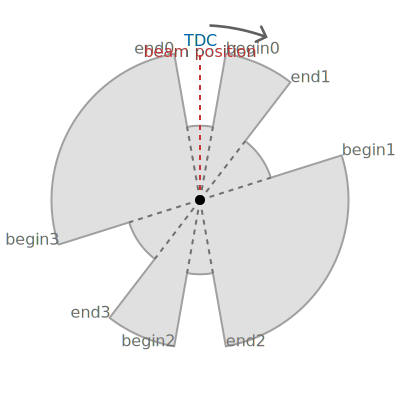

In [2]:
from typing import Literal
import scipp as sc
import tof
import plopp as pp
from instrument import Instrument
%matplotlib widget

T_OFFSET = sc.scalar(1700.0e-6, unit="s")
# T_OFFSET = sc.scalar(0.0, unit="s")
central_wavelength = 1 * sc.Unit("Å")
rrm: int = 8  # repetition rate multiplication factor
trex = Instrument(central_wavelength, rrm)
#trex.bw_chopper1().to_diskchopper()
trex.p_chopper2().to_diskchopper()
# trex.m_chopper1().to_diskchopper()

In [ ]:

central_wavelength = 1 * sc.Unit("Å")
rrm: int = 8  # repetition rate multiplication factor
mode: Literal["High Flux", "High Resolution"] = "High Flux"  # Chopper mode

#source = tof.Source(facility="ess", neutrons=500_000, pulses=1)  # type: ignore
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)

print(trex.calculate_toa_at("monitor3",RRM=False))
print(trex.calculate_delta_lambda())

<scipp.Variable> (toa: 1)    float64            [µs]  [42953.4]
<scipp.Variable> ()    float64             [Å]  0.218035


<scipp.Variable> (toa: 11)    float64            [µs]  [12971.1, 18967.5, ..., 66939.3, 72935.8]


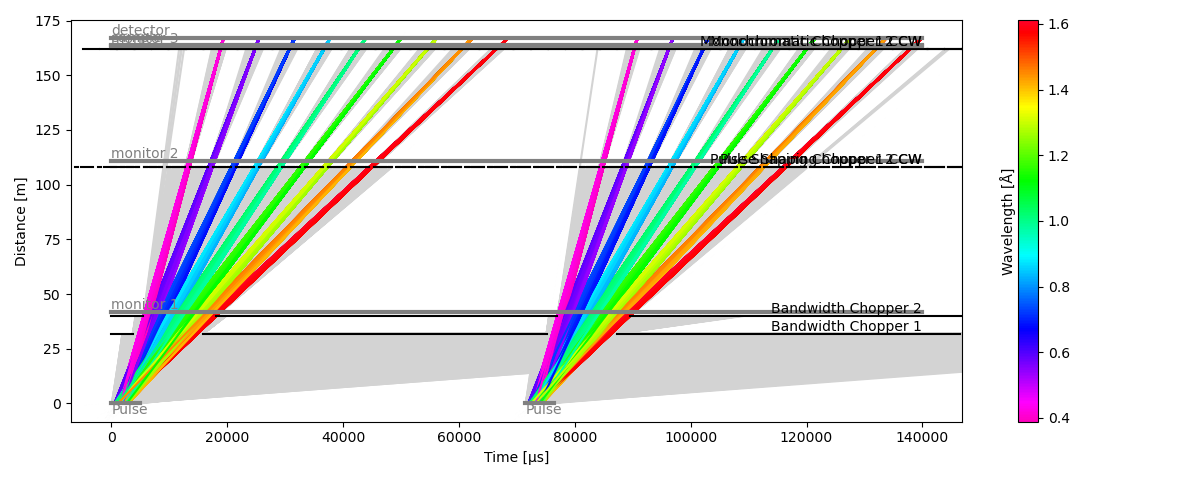

In [ ]:
T_OFFSET = sc.scalar(1700.0e-6, unit="s")
# T_OFFSET = sc.scalar(0.0, unit="s")
central_wavelength = sc.scalar(1.0, unit="Å")
rrm: int = 12 # repetition rate multiplication factor
mode = "High Flux"  # Chopper mode


trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = tof.Source(facility="ess", neutrons=5_000_000, pulses=2)
res = trex.model.run()
res.plot(visible_rays=1_000_000, blocked_rays=50_000)

print(trex.calculate_toa_at('monitor3',RRM=True))

In [13]:
print(trex.calculate_bandwidth())
res.choppers['Bandwidth Chopper 2'].wavelength.plot(grid=True)


(<scipp.Variable> ()    float64             [Å]  0.250111, <scipp.Variable> ()    float64             [Å]  1.78946)


InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [14]:
res = trex.model.run()
wavelength_data = res.detectors["sample"].wavelength.data 
#energy_data=tof.utils.speed_to_energy(tof.utils.wavelength_to_speed(wavelength_data))
# energy_dict[f"RRM={rrm}"] = energy_data.hist(wavelength=sc.linspace('wavelength', 0.25, 1.75, num=300,unit='Å'))
#tof.utils.wavelength_to_speed(wavelength_data)
tof.utils.wavelength_to_speed(wavelength_data.coords['wavelength'])

trex.model.detectors['monitor 3'].distance.value


np.float64(163.2)

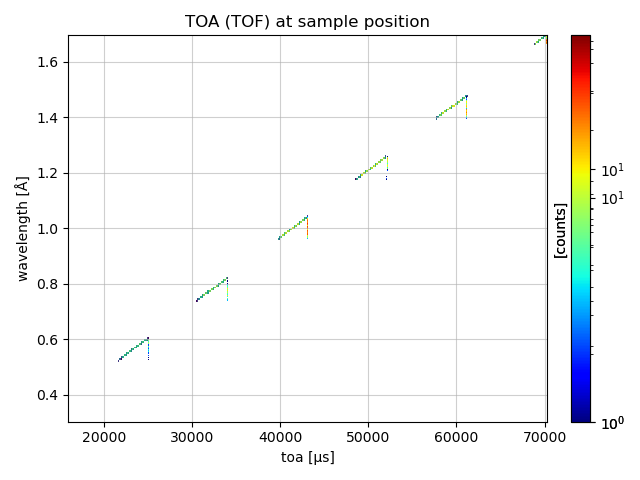

In [ ]:
central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

# Histogram and plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
tof_sample = events_at_sample.hist(wavelength=200, tof=500).plot(norm='log', ax=ax)
toa_sample = events_at_sample.hist(wavelength=400, toa=1000).plot(norm='log', cbar=True, 
                                                        ax=ax,cmap='jet', title='TOA (TOF) at sample position')

ax.grid(alpha=0.6)
fig.tight_layout()

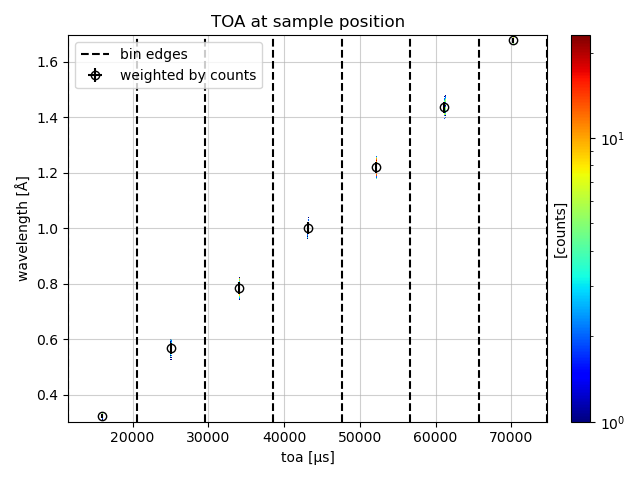

In [ ]:
central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()

# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]

# Histogram and plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(\
    norm='log', cbar=True, ax=ax,cmap='jet', title='TOA at sample position')

toa_centers = trex.calculate_toa_at("monitor_sample",RRM=True)
toa_bin_edges = trex.centers_to_edges(toa_centers)
for edge in toa_bin_edges:
    vline = ax.axvline(x = edge.values, c = 'k', linestyle='--',label = 'bin edges')


toa_binned = events_at_sample.bin(toa=toa_bin_edges)
# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords['wavelength']
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords['wavelength'] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# TOA mean of wavelength inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords['toa']
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords['toa'] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot=ax.errorbar(x=toa_mu.values, xerr= sc.sqrt(toa_var.hist()).values,
            y=wavelength_mu.values, yerr=sc.sqrt(wavelength_var.hist()).values, 
            fmt='ok', linestyle='', mfc='none',label='weighted by counts')
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[vline,ebplot])
fig.tight_layout()

In [44]:
events_at_sample

<scipp.DataArray>
Dimensions: Sizes[event:3544, ]
Coordinates:
* birth_time                float64            [µs]  (event)  [2175.81, 1825.67, ..., 3088.75, 970.622]
* distance                  float64              [m]  ()  163.8
* eto                       float64            [µs]  (event)  [43125.7, 52104, ..., 34015.5, 61173.2]
* id                          int64        <no unit>  (event)  [442, 523, ..., 999706, 999827]
* speed                     float64            [m/s]  (event)  [4000.01, 3257.86, ..., 5296.39, 2720.81]
* toa                       float64            [µs]  (event)  [43125.7, 52104, ..., 34015.5, 61173.2]
* tof                       float64            [µs]  (event)  [40949.9, 50278.4, ..., 30926.7, 60202.6]
* wavelength                float64             [Å]  (event)  [0.989006, 1.2143, ..., 0.74693, 1.45399]
Data:
                            float64         [counts]  (event)  [1, 1, ..., 1, 1]
Masks:
  blocked_by_others            bool        <no unit>  (event)  [False, False, ..., False, False]

In [46]:
trex.calculate_toa_at('monitor3', RRM=True)

<scipp.Variable> (toa: 7)    float64            [µs]  [15969.3, 24964, ..., 60942.9, 69937.6]

In [ ]:
central_wavelength = 1* sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()

toa_m3 = trex.calculate_toa_at('monitor3',RRM=True)
toa_m3_edge = trex.centers_to_edges(toa_m3)
toa_det = trex.calculate_toa_at('detector',RRM=True)
toa_det_edge = trex.centers_to_edges(toa_det)

toa_bin = sc.linspace('toa', toa_m3_edge.min(), toa_det_edge.max(), num=3000, unit='us')
hist_m3 = res.detectors['monitor 3'].toa.data.hist(toa=toa_bin) 
hist_det = res.detectors['detector'].toa.data.hist(toa=toa_bin)

pp.plot({'monitor 3': hist_m3, 'detector': hist_det},grid=True) # type: ignore

<scipp.DataArray>
Dimensions: Sizes[toa:2999, ]
Coordinates:
* toa                       float64            [µs]  (toa [bin-edge])  [11472, 11493.5, ..., 76017.8, 76039.4]
Data:
                            float64         [counts]  (toa)  [0, 0, ..., 0, 0]




InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [ ]:
# determine Ei based on TOA at Monitor 3 and Detector
ei = trex.find_ei_from_monitors(res.detectors['monitor 3'], res.detectors['detector'])
print(ei)

In [ ]:
# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
# Histogram and plot

In [ ]:
import matplotlib.pyplot as plt


binned = events_at_sample.bin(toa=1000)

# Weighted mean of wavelength inside each bin
wavelength_mu = (
    binned.bins.data * binned.bins.coords['wavelength']
).bins.sum() / binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    binned.bins.data * (binned.bins.coords['wavelength'] - wavelength_mu) ** 2
) / binned.bins.sum()

fig, ax = plt.subplots(2, 1)

tof = events_at_sample.hist(wavelength=200, tof=200).plot(norm='log', cbar=False, ax=ax[0], )
toa = events_at_sample.hist(wavelength=200, toa=200).plot(norm='log', cbar=False, ax=ax[1])
wavelength_mu.name = 'Wavelength'
wavelength_mu.plot(ax=ax[0], color='C1', grid=True)
stddev = sc.sqrt(wavelength_var.hist())
stddev.name = 'Standard deviation'
stddev.plot(marker='o', ax=ax[1], grid=True)
fig.set_size_inches(6, 8)
fig.tight_layout()

In [ ]:
wavelength_dict={}
central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm=4
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
while((trex.m_chopper1().frequency <trex.m_frequency_max )and (trex.p_chopper1().frequency <trex.p_frequency_max)):
    model = tof.Model(source=source, detectors=trex.detectors, choppers=trex.choppers)  # type: ignore
    res = model.run()
    wavelength_data = res.detectors["sample"].wavelength.data 
    wavelength_dict[f"RRM={rrm}"] = wavelength_data.hist(wavelength=sc.linspace('wavelength', 0.25, 1.75, num=300,unit='Å'))
    rrm += 4
    trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
pp.plot(wavelength_dict, figsize=(14,6), title=f"Wavelength Distribution at sample position, {mode} mode") # type: ignore

In [ ]:
wavelength_dict={}
energy_dict={}
central_wavelength = 1 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm=4
trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
while((trex.m_chopper1().frequency <trex.m_frequency_max )and (trex.p_chopper1().frequency <trex.p_frequency_max)):
    model = tof.Model(source=source, detectors=trex.detectors, choppers=trex.choppers)  # type: ignore
    res = model.run()
    wavelength_data = res.detectors["sample"].wavelength.data 
    wavelength_dict[f"RRM={rrm}"] = wavelength_data.hist(wavelength=sc.linspace('wavelength', 0.25, 1.75, num=300,unit='Å'))
    energy_data=tof.utils.speed_to_energy(tof.utils.wavelength_to_speed(wavelength_data))
    energy_dict[f"RRM={rrm}"] = energy_data.hist(wavelength=sc.linspace('wavelength', 0.25, 1.75, num=300,unit='Å'))
    rrm += 4
    trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
pp.plot(wavelength_dict, figsize=(14,6), title=f"Wavelength Distribution at sample position, {mode} mode") # type: ignore